# 03 - Causal Attention

In [2]:
import torch
import torch.nn as nn
inputs = torch.tensor([
    [0.43, 0.15, 0.89],
    [0.55, 0.87, 0.66],
    [0.57, 0.85, 0.64],
    [0.22, 0.58, 0.33],
    [0.77, 0.25, 0.10],
    [0.05, 0.80, 0.55],
])

d_in = inputs.shape[1]
d_out = 2

# To make sure this notebook remains standalone, we will paste the self attention version 2 that we implemented in notebook 2.

class SelfAttention_v2(nn.Module):
    def __init__ (self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5 , dim=-1)
        context_vec = attn_weights @ values
        return context_vec 

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)

Now, we will apply a causal attention mask. We do this so that each token can only use the context of itself and the tokens that came before it, without looking at future tokens.


The steps followed are in this order:

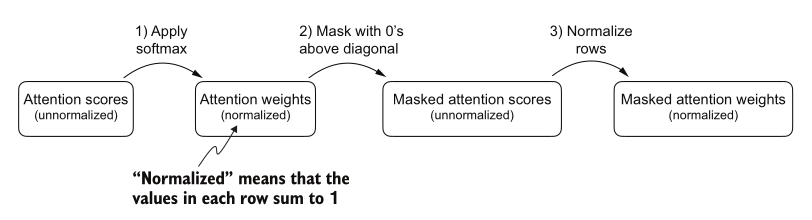

In [4]:
# Compute attention weights using softmax function 

queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights= torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
print(attn_weights)


tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [8]:
# Now, we are using PyTorch's tril function to create a mask where the values above the diagnoal are zero

context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))

# multiplying the mask with attention weights to zero-out the values above diagnoal

mask_simple = attn_weights*mask_simple
print(mask_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [ ]:
# The third step now is to renormalize the attention weights to sum up to 1

rows_sum = mask_simple.sum(dim=-1, keepdim=True)
mask_simple_norm = mask_simple / rows_sum
print(mask_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


Earlier, we applied softmax to the unmasked attention scores. Does that mean future tokens still influence the final attention weights?

No. After masking and renormalizing, each token assigns zero attention weight to all future tokens. The remaining weights are rescaled to sum to 1, so the context vector uses only the current token and preceding tokens.

Taking it a step further, let's implement the masked attention weights more efficiently with fewer steps using the property of softmax funciton.Detailed breakdown of this step will be available in my blog or you could refer to the book.

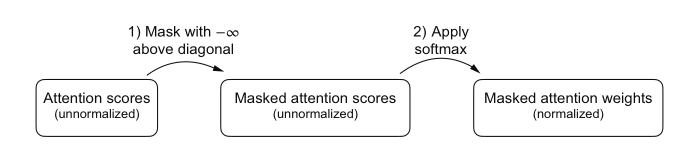

In [ ]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)
